# Lab 2 Part 2

This is an individual assignment.

---

Write your own code. You may repurpose any functions built during lecture. You may use ```scikit-learn``` functions.

---

## Custom Transformers

```scikit-learn``` offers many useful transformers, but you will likely need to write your own transformers for tasks such as custom cleanup operations or combining specific attributes.

To have your transformer working seamlessly with ```scikit-learn```, all you need to do is create a class and implement three methods: ```fit()``` (returning self), ```transform()```, and ```fit_transform()```.

You can get the last one for free by simply adding ```TransformerMixin``` as your base class. If you add ```BaseEstimator``` as a base class (and avoid ```*args``` and ```**kargs``` you will also get two extra methods (```get_params()``` and ```set_params()```) that will be useful for automatic hyperparameter tuning.

For example, for the dataset we discussed in lecture 3 (California housing prices), we can build a transformer to add the custom attributes as follows:

````python
from sklearn.base import BaseEstimator, TransformerMixin 

rooms_ix, bedrooms_ix, population_ix, households_ix = 3, 4, 5, 6 

class CombinedAttributesAdder(BaseEstimator, TransformerMixin): 
    def __init__ (self, add_bedrooms_per_room=True): # no *args or **kargs 
        self.add_bedrooms_per_room = add_bedrooms_per_room 
    def fit(self, X, y=None): 
        return self # nothing else to do 
    def transform(self, X): 
        rooms_per_household = X[:, rooms_ix] / X[:, households_ix] 
        population_per_household = X[:, population_ix] / X[:, households_ix] 
        if self.add_bedrooms_per_room: 
            bedrooms_per_room = X[:, bedrooms_ix] / X[:, rooms_ix] 
        return np.c_[X, rooms_per_household, population_per_household, bedrooms_per_room]
````

This transformer can later be added to a ```scikit-learn``` pipeline like this:

````python
from sklearn.pipeline import Pipeline 
from sklearn.preprocessing import StandardScaler 

num_pipeline = Pipeline([('imputer', SimpleImputer(strategy='median')), 
                         ('attribs_adder', CombinedAttributesAdder()), 
                         ('std_scaler', StandardScaler())]) 

housing_num_tr = num_pipeline.fit_transform(housing_num)
````

---

---

# Exercise 1 (50 points)

In this question, you will be working with the [marathon time predictions dataset](https://www.kaggle.com/datasets/girardi69/marathon-time-predictions).

### Attributes

* **id**: simple counter

* **Marathon**: the Marathon name where the data were extracted.

* **Name**: The athlete's name.

* **Category**: the sex and age group of a runner.
    * MAM Male Athletes under 40 years
    * WAM Women under 40 Years
    * M40 Male Athletes between 40 and 45 years

* **km4week**: This is the total number of kilometers run in the last 4 weeks before the marathon, marathon included. If, for example, the km4week is 100, the athlete has run 400 km in the four weeks before the marathon.

* **sp4week**: This is the average speed of the athlete in the last 4 training weeks. The average counts all the kilometers done, included the slow kilometers done before and after the training. A typical running session can be of 2km of slow running, then 12-14km of fast running, and finally other 2km of slow running. The average of the speed is this number, and with time this is one of the numbers that has to be refined.

* **cross training**: If the runner is also a cyclist, or a triathlete.

* **Wall21**: To acknowledge a good performance, as a marathoner, the first half marathon should be run with the same split of the second half. If, for example, I run the first half marathon in 1h30m, I must finish the marathon in 3h (for doing a good job). If I finish in 3h20m, I started too fast and I hit "the wall". My training history is, therefore, less valid, since I was not estimating my result.

* **Marathon time**: This is target value.

* **Category**: Categorical encoding of the target value. It groups in:
    * A results under 3h
    * B results between 3h and 3h20m
    * C results between 3h20m and 3h40m
    * D results between 3h40 and 4h

In [1]:
# Import libraries and magics
import numpy as np
import pandas as  pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
%matplotlib inline  

**Answer the following questions:**

1. (1 point) **Load the data with ```pandas```.**

In [2]:
df = pd.read_csv('MarathonData.csv')
df

,id,Marathon,Name,Category,km4week,sp4week,CrossTraining,Wall21,MarathonTime,CATEGORY
0,1,Prague17,Blair MORGAN,MAM,132.8,14.434783,NaN,1.16,2.37,A
1,2,Prague17,Robert Heczko,MAM,68.6,13.674419,NaN,1.23,2.59,A
2,3,Prague17,Michon Jerome,MAM,82.7,13.520436,NaN,1.30,2.66,A
3,4,Prague17,Daniel Or lek,M45,137.5,12.258544,NaN,1.32,2.68,A
4,5,Prague17,Luk ? Mr zek,MAM,84.6,13.945055,NaN,1.36,2.74,A
...,...,...,...,...,...,...,...,...,...,...
82,83,Prague17,Stefano Vegliani,M55,50.0,10.830325,NaN,2.02,3.93,D
83,84,Prague17,Andrej Madliak,M40,33.6,10.130653,ciclista 3h,1.94,3.93,D
84,85,Prague17,Yoi Ohsako,M40,55.4,11.043189,NaN,1.94,3.94,D
85,86,Prague17,Simon Dunn,M45,33.2,11.066667,NaN,2.05,3.95,D


2. (3 points) **Are there missing samples? Determine which approach you are going to use to handle missing data. All justifications and reasoning must be included in a markdown cell.**

In [3]:
print(df.isnull().sum())

id                0
Marathon          0
Name              0
Category          6
km4week           0
sp4week           0
CrossTraining    74
Wall21            0
MarathonTime      0
CATEGORY          0
dtype: int64


1. We can know that the NaN in CrossTraining means that he is triathlete so we only have to change the NaN into triathlete

2. We also knows that we got 6 NaN in Category, the Category is about the age and its gender, because its NaN so Ill just delete it.

In [4]:
df["CrossTraining"] = df["CrossTraining"].fillna("triathlete")
df = df.dropna(subset=["Category"])

print(df.isnull().sum())

df

id               0
Marathon         0
Name             0
Category         0
km4week          0
sp4week          0
CrossTraining    0
Wall21           0
MarathonTime     0
CATEGORY         0
dtype: int64


,id,Marathon,Name,Category,km4week,sp4week,CrossTraining,Wall21,MarathonTime,CATEGORY
0,1,Prague17,Blair MORGAN,MAM,132.8,14.434783,triathlete,1.16,2.37,A
1,2,Prague17,Robert Heczko,MAM,68.6,13.674419,triathlete,1.23,2.59,A
2,3,Prague17,Michon Jerome,MAM,82.7,13.520436,triathlete,1.30,2.66,A
3,4,Prague17,Daniel Or lek,M45,137.5,12.258544,triathlete,1.32,2.68,A
4,5,Prague17,Luk ? Mr zek,MAM,84.6,13.945055,triathlete,1.36,2.74,A
...,...,...,...,...,...,...,...,...,...,...
82,83,Prague17,Stefano Vegliani,M55,50.0,10.830325,triathlete,2.02,3.93,D
83,84,Prague17,Andrej Madliak,M40,33.6,10.130653,ciclista 3h,1.94,3.93,D
84,85,Prague17,Yoi Ohsako,M40,55.4,11.043189,triathlete,1.94,3.94,D
85,86,Prague17,Simon Dunn,M45,33.2,11.066667,triathlete,2.05,3.95,D


The data changes from 87 rows × 10 columns to 81 rows × 10 columns

3. (3 points) **Print the Pearson's correlation matrix and visualize the data. Which attribute has the largest predictive value to predict the marathon time?**

In [5]:
df.dtypes

id                 int64
Marathon          object
Name              object
Category          object
km4week          float64
sp4week          float64
CrossTraining     object
Wall21            object
MarathonTime     float64
CATEGORY          object
dtype: object

In [6]:
df['Wall21'] = pd.to_numeric(df['Wall21'])

C:\Users\champ\AppData\Local\Temp\ipykernel_9796\2597756501.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Wall21'] = pd.to_numeric(df['Wall21'])


In [7]:
numeric_df = df.select_dtypes(include=['float64', 'int64'])

corr_matrix = numeric_df.corr()

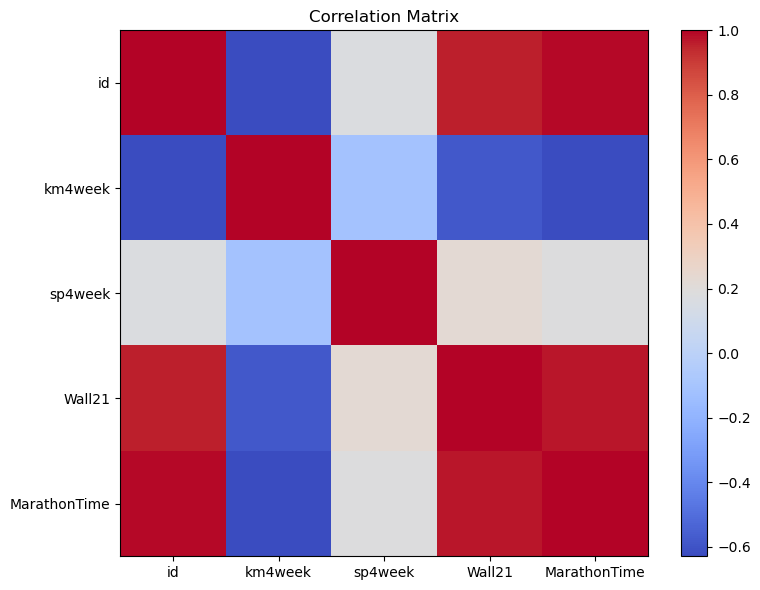

In [8]:
plt.figure(figsize=(8, 6))
plt.imshow(corr_matrix, cmap='coolwarm', aspect='auto')
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()


In [9]:
print(corr_matrix['MarathonTime'].sort_values(ascending=False))

MarathonTime    1.000000
id              0.991353
Wall21          0.969089
sp4week         0.180594
km4week        -0.629511
Name: MarathonTime, dtype: float64


ID should be the ranking of the  Marathon

4. (9 points) **Create a new attribute that computes the ratio between the ```km4week``` and ```sp4week```. Build a custom transformer to automate this feature extraction (see example at the top of this notebook).**

In [10]:
class TrainingRatioTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, km4week_idx=1, sp4week_idx=2):  #
        self.km4week_idx = km4week_idx
        self.sp4week_idx = sp4week_idx
        
    def fit(self, X, y=None):
        return self
        
    def transform(self, X):
        X_copy = np.copy(X)
        training_ratio = X_copy[:, self.km4week_idx] / X_copy[:, self.sp4week_idx]
        return np.c_[X_copy, training_ratio]

In [11]:
num_pipeline = Pipeline([
    ('training_ratio', TrainingRatioTransformer()),
    ('std_scaler', StandardScaler())
])

In [12]:
num_pipeline

Pipeline(steps=[('training_ratio', TrainingRatioTransformer()),
                ('std_scaler', StandardScaler())])

5. (3 points) **Partition the data into training and test sets. If you use stratified partition, justify your answer.**

In [13]:
numeric_df

,id,km4week,sp4week,Wall21,MarathonTime
0,1,132.8,14.434783,1.16,2.37
1,2,68.6,13.674419,1.23,2.59
2,3,82.7,13.520436,1.30,2.66
3,4,137.5,12.258544,1.32,2.68
4,5,84.6,13.945055,1.36,2.74
...,...,...,...,...,...
82,83,50.0,10.830325,2.02,3.93
83,84,33.6,10.130653,1.94,3.93
84,85,55.4,11.043189,1.94,3.94
85,86,33.2,11.066667,2.05,3.95


In [14]:
X_train, X_test, Y_train, Y_test = train_test_split(
    df.drop('MarathonTime', axis=1), 
    df['MarathonTime'],              
    test_size=0.2,                    
    random_state=2025,                  
    stratify=df['Category']           
)

In [15]:
X_test.shape,X_train.shape

((17, 9), (64, 9))

In [16]:
Y_train.shape, Y_test.shape

((64,), (17,))

6. (3 points) **Build a transformation pipeline with ```scikit-learn``` to encode any categorical attributes.**

In [17]:
columns_name = df.select_dtypes(include=['object', 'category']).columns
columns_name

Index(['Marathon', 'Name', 'Category', 'CrossTraining', 'CATEGORY'], dtype='object')

In [18]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(
            drop='first',  
            sparse_output=False,  
            handle_unknown='ignore', 
            dtype=float
        ), ['Category', 'CrossTraining', 'CATEGORY'])  
    ])

In [19]:
pipeline = Pipeline([
    ('preprocessor', preprocessor)
])

7. (15 points) **Build a transformation pipeline with ```scikit-learn``` to encode the numerical attributes. This pipeline should include your custom transformer built in step 4.**

In [20]:
numeric_features = ['id', 'km4week', 'sp4week', 'Wall21']
num_pipeline = Pipeline([
    ('training_ratio', TrainingRatioTransformer(
        km4week_idx=numeric_features.index('km4week'),
        sp4week_idx=numeric_features.index('sp4week')
    )),
    ('scaler', StandardScaler())
])

numeric_preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, numeric_features)
    ])

8. (13 points) **Build a transformation pipeline that combines both categorical and numerical attributes.**

In [21]:
numeric_features = ['km4week', 'sp4week', 'Wall21']  
categorical_features = ['Category', 'CrossTraining', 'CATEGORY']

In [22]:
full_pipeline = Pipeline([
    ('preprocessor', ColumnTransformer(
        transformers=[
            ('num', Pipeline([
                ('ratio', TrainingRatioTransformer(
                    km4week_idx=numeric_features.index('km4week'),
                    sp4week_idx=numeric_features.index('sp4week')
                )),
                ('scaler', StandardScaler())
            ]), numeric_features),
            
            ('cat', OneHotEncoder(
                drop='first',
                sparse_output=False,
                handle_unknown='ignore',
                dtype=float
            ), categorical_features)
        ],
        remainder='drop'  
    ))
])


---

___

# Submit Your Solution

Confirm that you've successfully completed the assignment.

Along with the Notebook, include a PDF of the notebook with your solutions.

```add``` and ```commit``` the final version of your work, and ```push``` your code to your GitHub repository.

Submit the URL of your GitHub Repository as your assignment submission on Canvas.

___